# Explanatory Data Analysis

In [58]:
import kagglehub
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import find_peaks


In [59]:
# Download latest version
path = kagglehub.dataset_download("danizo/eeg-dataset-for-adhd")

p = Path(path)

In [60]:
df = pd.read_csv(p/"adhdata.csv")

In [61]:
print(df.shape)

(2166383, 21)


## Opis datasetu i struktury

Dane składają się z 21 kolumn oraz 2 166 383 wierszy.

19 kanałów to elektrody pobierające sygnał EEG, ID to identyfikator pacjenta (choć błędnie nazwany, gdyż z datasetu wynika, że było 121 pacjentów, więc ID oznacza numer sesji badania, a niektóre sesje były powtarzane dla tych samych pacjentów).

Wiersze przedstawiają szeregi czasowe dla 350 prób, podczas których badano sygnały EEG u dzieci. Jednostką pomiaru był pV.

Klasa określa, czy dziecko ma ADHD, czy nie.

Uczestnicy to 61 dzieci z ADHD i 60 zdrowych kontrolnych (chłopcy i dziewczynki, w wieku 7-12 lat). Dzieci z ADHD zostały zdiagnozowane przez doświadczonego psychiatry zgodnie z kryteriami DSM-IV i przyjmowały Ritalin przez maksymalnie 6 miesięcy. Żadne z dzieci w grupie kontrolnej nie miało historii zaburzeń psychiatrycznych, epilepsji ani żadnych zgłoszeń ryzykownych zachowań.

Rejestracja EEG została wykonana zgodnie ze standardem 10-20 przy użyciu 19 kanałów (Fz, Cz, Pz, C3, T3, C4, T4, Fp1, Fp2, F3, F4, F7, F8, P3, P4, T5, T6, O1, O2) z częstotliwością próbkowania 128 Hz. Elektrody A1 i A2 były referencyjne, umieszczone na płatkach uszu.

## Sanity check 

Wartości sygnałów ustawiamy na inty, class jako zmienna kategoryczną.



In [62]:
for col in df.columns[:-2]:
    df[col] = df[col].astype(int)
df["Class"] = df["Class"].astype("category")

## Kontrola jakości danych

Podczas przeglądania danych, nie wykryłem żadnego nie standardowego zapisu obserwacji odstających, jak i nie ma w zbiorze danych samych obserwacji odstających.

Długości serii są różne, ze względu na to , że badania przeprowadzano do momentu zakończenia odpowiedzi dziecka.
A długość odpowiedzi dzieci zależała od wielu różnych niezależnych czynników

Częstotliwość próbkowania wynosiła 128Hz, czyli jeżeli podzielimy ilośc próbek w każdej sesji przez 128, to uzyskamy długość trawania sesji w sekundach.

In [63]:
print(max(df.groupby("ID").size())/128)
print(min(df.groupby("ID").size())/128)

337.90625
62.3671875


Najdłuższa zesja trwałą ok 5.5 minut a najkrutsza ok jednej minuty. Więc występują istotne różnice w długości trwania sesji.

In [64]:

lengths = df.groupby('ID').size() / 128

classes = df.groupby('ID')['Class'].first()

session_info = pd.concat([classes, lengths.rename('duration')], axis=1)
avg_by_class = session_info.groupby('Class')['duration'].mean()
print(avg_by_class)

Class
ADHD       154.593878
Control    124.910677
Name: duration, dtype: float64


Widać, że sesje średnio trwał dłużej dla dzieci z ADHD, niż bez niego

In [65]:
# rozszerz tabelę cech o dodatkowe cechy


# kanały EEG
channels = df.columns[:-2]

# cechy statystyczne, spektralne, nieliniowe dla każdego kanału w każdej sesji
features = []

for id_val in df['ID'].unique():
    session_data = df[df['ID'] == id_val]
    class_val = session_data['Class'].iloc[0]
    duration = len(session_data) / 128 
    row = {'ID': id_val, 'Class': class_val, 'duration': duration}

    for ch in channels:
        series = session_data[ch].values
        # statystyczne rozszerzone
        row[f'{ch}_mean'] = np.mean(series)
        row[f'{ch}_std'] = np.std(series)
        row[f'{ch}_skew'] = pd.Series(series).skew()
        row[f'{ch}_kurt'] = pd.Series(series).kurtosis()

        # RMS
        row[f'{ch}_rms'] = np.sqrt(np.mean(series**2))

        # energia (suma kwadratów)
        row[f'{ch}_energy'] = np.sum(series**2)

        # liczba pików (lokalne maksima)
        peaks, _ = find_peaks(series)
        row[f'{ch}_peaks'] = len(peaks)

        # spektralne: moc w pasmach (FFT)
        fft = np.fft.fft(series)
        power = np.abs(fft)**2
        freqs = np.fft.fftfreq(len(series), d=1/128)
        # pasma: delta (0-4), theta (4-8), alpha (8-12), beta (12-30)

        for band, (low, high) in [('delta', (0,4)), ('theta', (4,8)), ('alpha', (8,12)), ('beta', (12,30))]:
            mask = (freqs >= low) & (freqs < high)
            row[f'{ch}_{band}_power'] = np.sum(power[mask]) / np.sum(power)  # względna moc
            
        # nieliniowe: entropia spektralna (prosta aproksymacja)
        power_norm = power / np.sum(power)
        row[f'{ch}_spectral_entropy'] = -np.sum(power_norm * np.log2(power_norm + 1e-10))
    features.append(row)

# utwórz DataFrame cech
features_df = pd.DataFrame(features)


In [66]:
import numpy as np
import pandas as pd

# bierzemy tylko cechy, bez ID
X = features_df.drop(columns=['ID'])

# tylko kolumny numeryczne
X_num = X.select_dtypes(include=[np.number])

corr = X_num.corr(method='pearson')
corr.head()

,duration,Fp1_mean,Fp1_std,Fp1_skew,Fp1_kurt,Fp1_rms,Fp1_energy,Fp1_peaks,Fp1_delta_power,Fp1_theta_power,...,Pz_skew,Pz_kurt,Pz_rms,Pz_energy,Pz_peaks,Pz_delta_power,Pz_theta_power,Pz_alpha_power,Pz_beta_power,Pz_spectral_entropy
duration,1.000000,-0.062964,-0.049668,0.048086,-0.037591,-0.051403,0.344651,0.775222,0.065149,0.159317,...,-0.032587,0.044281,-0.015388,0.251517,0.723173,0.045767,0.055513,0.013715,0.042907,0.211633
Fp1_mean,-0.062964,1.000000,0.126685,0.161618,0.100558,0.150829,0.101117,0.061774,0.035942,-0.180543,...,0.031168,-0.067331,0.105066,0.047616,0.069969,0.007362,-0.197076,-0.113167,-0.189804,-0.155682
Fp1_std,-0.049668,0.126685,1.000000,0.014326,0.051747,0.998790,0.866295,0.094797,-0.616436,-0.260983,...,-0.086147,0.049899,0.706115,0.531286,0.148824,-0.488283,-0.251620,-0.200215,-0.200151,0.356382
Fp1_skew,0.048086,0.161618,0.014326,1.000000,0.238667,0.015734,0.024919,0.062077,-0.066771,0.226060,...,0.566739,-0.091628,-0.021178,0.004154,0.026308,-0.097718,0.193529,0.159071,-0.023509,-0.054102
Fp1_kurt,-0.037591,0.100558,0.051747,0.238667,1.000000,0.048178,-0.006815,-0.037863,0.024213,-0.003453,...,0.078559,0.485882,0.010586,-0.030909,0.002442,-0.082552,0.109661,0.337149,0.079130,0.170780


In [67]:
# policz średnie dla każdej cechy (numeryczne) w zależności od klasy
class_means = features_df.groupby('Class')[features_df.columns.difference(['ID', 'Class'])].mean()

# jeśli chcesz porównanie (ADHD - Control)
diff = class_means.loc['ADHD'] - class_means.loc['Control']


In [68]:
from scipy.stats import mannwhitneyu

# podział na dwie grupy
adhd_data = features_df[features_df['Class'] == 'ADHD']
control_data = features_df[features_df['Class'] == 'Control']

# test Mann-Whitney dla każdej cechy
p_values = {}
for col in features_df.columns.difference(['ID', 'Class']):
    stat, p = mannwhitneyu(adhd_data[col], control_data[col])
    p_values[col] = p

# sortuj po p-value, wyświetl istotne (p < 0.05)
p_values_sorted = sorted(p_values.items(), key=lambda x: x[1])


## Wizualizacja przykładowych serii

Przykładowa serja dla pacjenta z ADHD

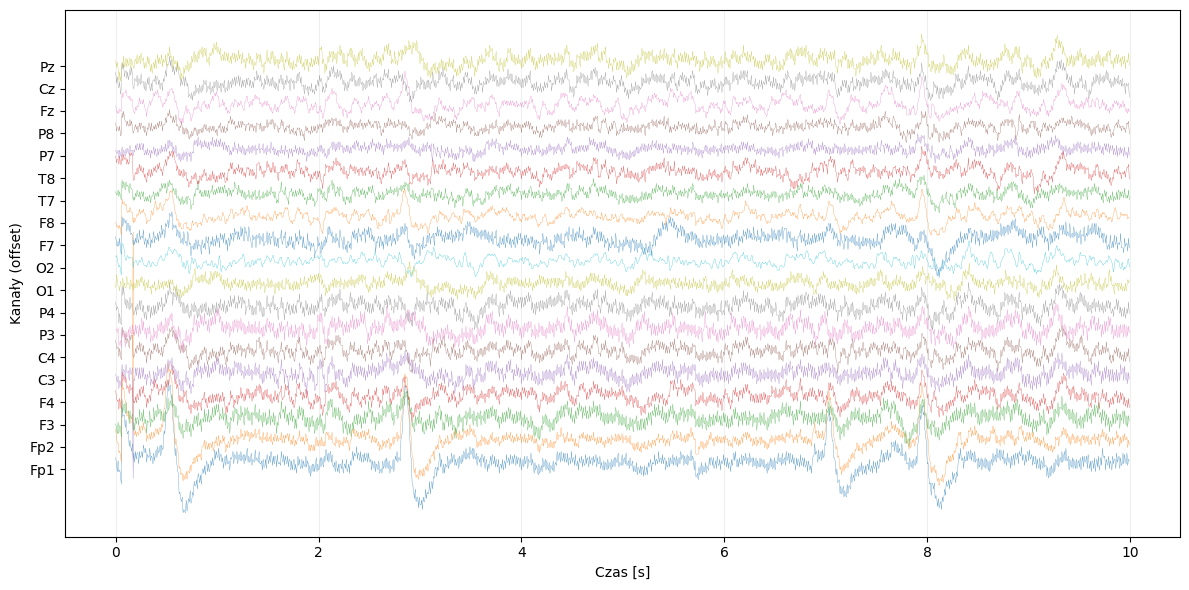

In [69]:

fs = 128
row = df.loc[df["ID"] == "v10p"].select_dtypes("number").reset_index(drop=True)
def visualization(row: pd.DataFrame) -> None :
    seg = row.iloc[: fs * 10] 
    channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7',
        'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
    offset = 500  
    t = np.arange(len(seg)) / fs

    plt.figure(figsize=(12, 6))
    for i, ch in enumerate(channels):
        sig = seg[ch].to_numpy()
        plt.plot(t, sig + i*offset, lw=0.2, color=f"C{i%10}")
    plt.yticks(np.arange(len(channels))*offset, channels)
    plt.xlabel("Czas [s]")
    plt.ylabel("Kanały (offset)")
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

visualization(row)


In [70]:
row = df.loc[df["ID"] == "v310"].select_dtypes("number").reset_index(drop=True)

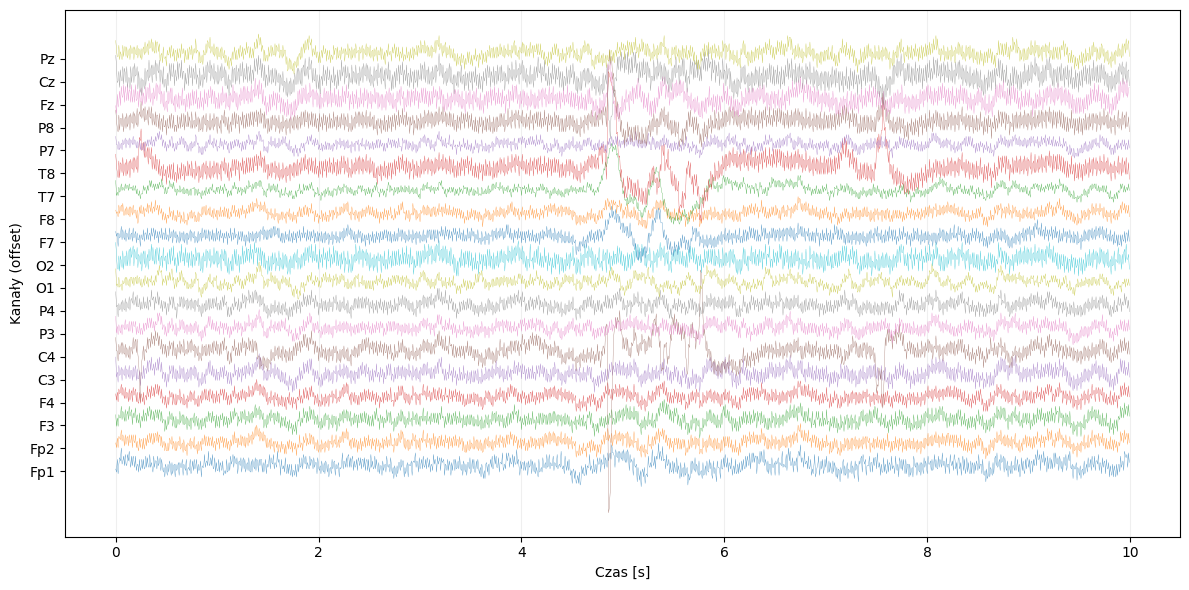

In [71]:
visualization(row)

Dla przykładowych danych, widać znaczne różnice dla pierwszych 10-ciu sekund dla pacjenta z ADHD, oraz bez ADHD. 
Dla pacjenta z ADHD, znacznie więcej wzniesień pojawia się dla początku i końca okresu, natomiast dla pacjenta bez ADHD, większość wariancji próby przejawia się w środkowym przebiegu badania

Dla niektórych kanałów widać bardzo podobny przebieg, co świadczy o możliwości usunięcia niepotrzebnych kanałów. Dla każdej próby wedłóg klasy policzymy korelację między kanałami, następnie policzymy odpowiednie średnie korelacje między kanałami a także wariancje miedzy nimi. Jeżeli korelacja będzie duża a wariancja mała, to z danej pary zostawiamy tylko jeden kanał

In [73]:

channels = df.columns[:-2]   # zakladamy, ze ostatnie 2 kolumny to ID i Class

# korelacja osobno dla kazdej pary (Class, ID)
corr_by_class_id = df.groupby(["Class", "ID"])[channels].corr(method="pearson")

mean_corr_by_class = corr_by_class_id.groupby(level=[0, 2]).mean()
std_corr_by_class = corr_by_class_id.groupby(level=[0, 2]).std()

# dostepne etykiety klas (np. 'ADHD', 'Control')
classes = mean_corr_by_class.index.get_level_values(0).unique().to_list()

mean_by_class = {c: mean_corr_by_class.xs(c, level=0) for c in classes}
std_by_class = {c: std_corr_by_class.xs(c, level=0) for c in classes}

import matplotlib.pyplot as plt
import seaborn as sns

for c in classes:
    plt.figure(figsize=(8, 6))
    sns.heatmap(mean_by_class[c], cmap="coolwarm", vmin=-1, vmax=1, annot=True)
    plt.title(f"Srednia korelacja - klasa {c}")
    plt.tight_layout()
    plt.show()


KeyError: 0

In [55]:
print(mean_corr_by_class)

                  Fp1       Fp2        F3        F4        C3        C4  \
Class                                                                     
ADHD    C3   0.505695  0.278863  0.726890  0.433754  1.000000  0.472664   
        C4   0.299123  0.432177  0.419987  0.671331  0.472664  1.000000   
        Cz   0.263088  0.401192  0.383498  0.600332  0.497255  0.716116   
        F3   0.751626  0.468009  1.000000  0.581796  0.726890  0.419987   
        F4   0.488877  0.655869  0.581796  1.000000  0.433754  0.671331   
        F7   0.630566  0.386731  0.672787  0.399611  0.514470  0.305227   
        F8   0.396089  0.593962  0.389033  0.628079  0.296135  0.474660   
        Fp1  1.000000  0.644239  0.751626  0.488877  0.505695  0.299123   
        Fp2  0.644239  1.000000  0.468009  0.655869  0.278863  0.432177   
        Fz   0.647747  0.460839  0.798074  0.594744  0.613753  0.409096   
        O1   0.197385  0.033849  0.286916  0.072478  0.432126  0.179215   
        O2   0.063355  0.

## Analiza rozkładów cech pomiędzy seriami

## Właściwa analiza czasowa na wybranych seriach

## Analiza pomiędzy seriami i względem targetu

## Analiza częstotliwościowa

## Wnioski i plan preprocessingu